In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from xgboost import XGBClassifier, XGBRegressor

DATA_FOLDER = "/Users/shilppatel/Desktop/AA_FINAL_PROJECT"

# Load the final modeling dataset
df = pd.read_csv(os.path.join(DATA_FOLDER, "modeling_dataset.csv"), low_memory=False)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Shape: 211,800 rows x 35 columns


In [2]:
# quick look at what we have before building anything
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nTarget class balance:")
print(df['CHANGE_FLAG_10MIN'].value_counts())
print(f"\nPositive rate: {df['CHANGE_FLAG_10MIN'].mean()*100:.2f}%")
print(f"\nData types with nulls:")
print(df.dtypes[df.isnull().any()])
print(f"\nTotal nulls: {df.isnull().sum().sum()}")


Shape: 211,800 rows x 35 columns

Columns:
['LEG_DEP_VARNCE_MIN_QTY', 'LEG_ARVL_VARNCE_MIN_QTY', 'POST_NBR', 'SUBSEQUENT_LEG_OF_DIVERT_IND', 'flight_duration_min', 'dep_LNGST_RUNWAY_FT_QTY', 'dep_ELEVATN_FT_QTY', 'dep_airport_latitude', 'dep_airport_longitude', 'arvl_LNGST_RUNWAY_FT_QTY', 'arvl_ELEVATN_FT_QTY', 'arvl_airport_latitude', 'arvl_airport_longitude', 'dep_wind_speed', 'dep_visibility', 'dep_precipitation', 'arvl_wind_speed', 'arvl_visibility', 'arvl_precipitation', 'dep_hour', 'dep_dayofweek', 'dep_month', 'weather_delay_flag', 'CHANGE_FLAG_1MIN', 'CHANGE_FLAG_10MIN', 'DEP_STATUS_DESC_ENC', 'ARVL_STATUS_DESC_ENC', 'OP_PRE_STATUS_CD_ENC', 'OP_STATUS_CD_ENC', 'OPERAT_AIRLN_IATA_CD_ENC', 'SCHD_FLEET_CD_ENC', 'ACTL_FLEET_CD_ENC', 'SCHD_LEG_ARVL_AIRPRT_IATA_CD_ENC', 'dep_wxcodes_ENC', 'arvl_wxcodes_ENC']

Target class balance:
CHANGE_FLAG_10MIN
1    170272
0     41528
Name: count, dtype: int64

Positive rate: 80.39%

Data types with nulls:
Series([], dtype: object)

Total nulls: 

In [3]:
# drop both targets and the 1-min flag — these would leak the answer
feature_cols = [col for col in df.columns if col not in [
    'LEG_ARVL_VARNCE_MIN_QTY',
    'CHANGE_FLAG_1MIN',
    'CHANGE_FLAG_10MIN'
]]

X = df[feature_cols]
y = df['CHANGE_FLAG_10MIN']

# stratify keeps the 80/20 class balance in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features       : {X_train.shape[1]}")
print(f"Training rows  : {X_train.shape[0]:,}")
print(f"Test rows      : {X_test.shape[0]:,}")
print(f"\nTrain class balance: {y_train.mean()*100:.2f}% positive")
print(f"Test class balance : {y_test.mean()*100:.2f}% positive")


Features       : 32
Training rows  : 169,440
Test rows      : 42,360

Train class balance: 80.39% positive
Test class balance : 80.39% positive


In [4]:
from sklearn.preprocessing import StandardScaler

# scale features — logistic regression requires this to converge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# baseline model with balanced class weight to handle 80/20 imbalance
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr  = lr.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression — Baseline")
print("="*40)
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['On Time', 'Late 10+']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))


Logistic Regression — Baseline
Accuracy : 0.8627
AUC-ROC  : 0.9481

Classification Report:
              precision    recall  f1-score   support

     On Time       0.60      0.93      0.73      8306
    Late 10+       0.98      0.85      0.91     34054

    accuracy                           0.86     42360
   macro avg       0.79      0.89      0.82     42360
weighted avg       0.90      0.86      0.87     42360

Confusion Matrix:
[[ 7726   580]
 [ 5237 28817]]


In [5]:
# random forest — no scaling needed, handles raw features directly
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("="*40)
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['On Time', 'Late 10+']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


Random Forest
Accuracy : 0.8931
AUC-ROC  : 0.9488

Classification Report:
              precision    recall  f1-score   support

     On Time       0.73      0.72      0.73      8306
    Late 10+       0.93      0.93      0.93     34054

    accuracy                           0.89     42360
   macro avg       0.83      0.83      0.83     42360
weighted avg       0.89      0.89      0.89     42360

Confusion Matrix:
[[ 5999  2307]
 [ 2220 31834]]


In [6]:
# scale_pos_weight handles imbalance for xgboost — ratio of negatives to positives
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb = XGBClassifier(
    scale_pos_weight=neg / pos,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb  = xgb.predict_proba(X_test)[:, 1]

print("XGBoost")
print("="*40)
print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['On Time', 'Late 10+']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))


XGBoost
Accuracy : 0.8753
AUC-ROC  : 0.9555

Classification Report:
              precision    recall  f1-score   support

     On Time       0.62      0.93      0.75      8306
    Late 10+       0.98      0.86      0.92     34054

    accuracy                           0.88     42360
   macro avg       0.80      0.90      0.83     42360
weighted avg       0.91      0.88      0.88     42360

Confusion Matrix:
[[ 7732   574]
 [ 4707 29347]]


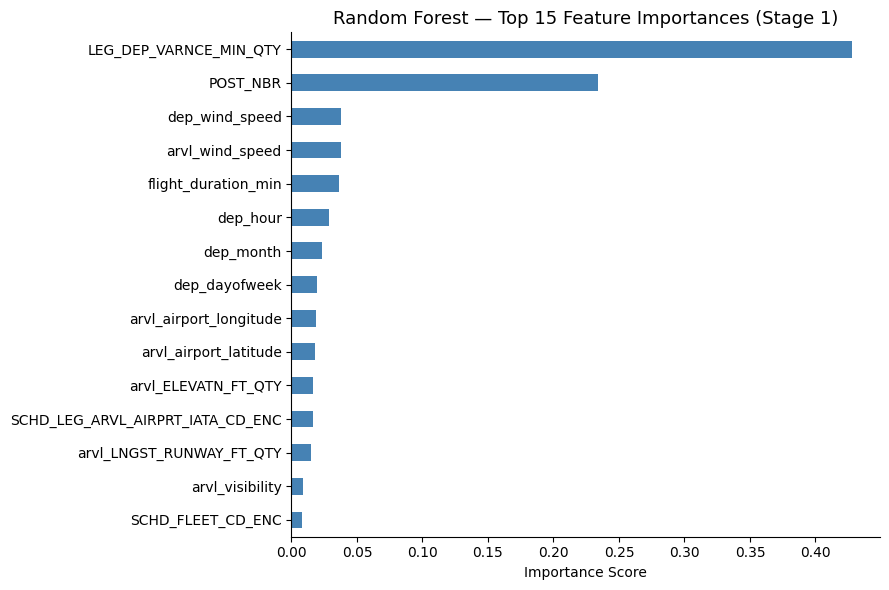

Saved to AA_FINAL_PROJECT folder


In [7]:
import matplotlib.pyplot as plt

# get feature importances from the trained random forest
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True).tail(15)

# horizontal bar chart — easier to read feature names
fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')

ax.set_title('Random Forest — Top 15 Feature Importances (Stage 1)', fontsize=13)
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/shilppatel/Desktop/AA_FINAL_PROJECT/stage1_feature_importance.png', dpi=150)
plt.show()
print("Saved to AA_FINAL_PROJECT folder")


In [8]:
# keep only flights that actually arrived 10+ minutes late
df_stage2 = df[df['CHANGE_FLAG_10MIN'] == 1].copy()

X2 = df_stage2[feature_cols]
y2 = df_stage2['LEG_ARVL_VARNCE_MIN_QTY']

# standard 80/20 split — no need to stratify for regression
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

print(f"Stage 2 rows    : {df_stage2.shape[0]:,}")
print(f"Training rows   : {X2_train.shape[0]:,}")
print(f"Test rows       : {X2_test.shape[0]:,}")
print(f"\nTarget (arrival variance) stats:")
print(y2.describe().round(1))


Stage 2 rows    : 170,272
Training rows   : 136,217
Test rows       : 34,055

Target (arrival variance) stats:
count    170272.0
mean         76.8
std          79.4
min          10.0
25%          27.0
50%          51.0
75%          96.0
max         485.0
Name: LEG_ARVL_VARNCE_MIN_QTY, dtype: float64


In [9]:
from sklearn.linear_model import LinearRegression

# baseline — simplest possible regression model
lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)

y2_pred_lr = lr2.predict(X2_test)

print("Linear Regression — Baseline")
print("="*40)
print(f"MAE  : {mean_absolute_error(y2_test, y2_pred_lr):.2f} minutes")
print(f"RMSE : {np.sqrt(mean_squared_error(y2_test, y2_pred_lr)):.2f} minutes")
print(f"R²   : {r2_score(y2_test, y2_pred_lr):.4f}")


Linear Regression — Baseline
MAE  : 11.08 minutes
RMSE : 16.36 minutes
R²   : 0.9588


In [10]:
from sklearn.ensemble import RandomForestRegressor

# random forest regressor — no scaling needed
rf2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X2_train, y2_train)

y2_pred_rf = rf2.predict(X2_test)

print("Random Forest Regressor")
print("="*40)
print(f"MAE  : {mean_absolute_error(y2_test, y2_pred_rf):.2f} minutes")
print(f"RMSE : {np.sqrt(mean_squared_error(y2_test, y2_pred_rf)):.2f} minutes")
print(f"R²   : {r2_score(y2_test, y2_pred_rf):.4f}")


Random Forest Regressor
MAE  : 10.56 minutes
RMSE : 15.56 minutes
R²   : 0.9627


In [11]:
from xgboost import XGBRegressor

# xgboost regressor
xgb2 = XGBRegressor(random_state=42, n_jobs=-1)
xgb2.fit(X2_train, y2_train)

y2_pred_xgb = xgb2.predict(X2_test)

print("XGBoost Regressor")
print("="*40)
print(f"MAE  : {mean_absolute_error(y2_test, y2_pred_xgb):.2f} minutes")
print(f"RMSE : {np.sqrt(mean_squared_error(y2_test, y2_pred_xgb)):.2f} minutes")
print(f"R²   : {r2_score(y2_test, y2_pred_xgb):.4f}")


XGBoost Regressor
MAE  : 9.90 minutes
RMSE : 14.78 minutes
R²   : 0.9663


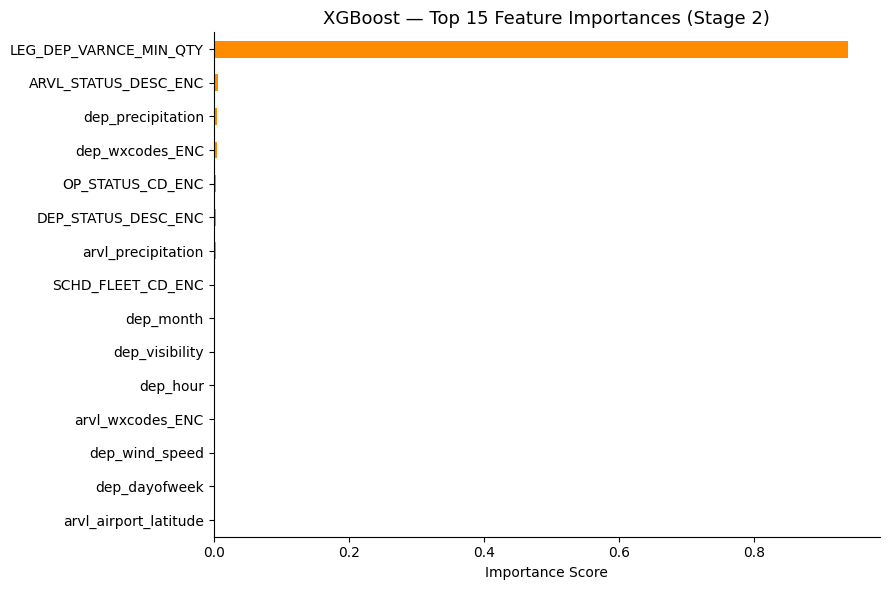

Saved to AA_FINAL_PROJECT folder


In [12]:
# get feature importances from the trained xgboost regressor
importances2 = pd.Series(xgb2.feature_importances_, index=feature_cols)
importances2 = importances2.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
importances2.plot(kind='barh', ax=ax, color='darkorange')

ax.set_title('XGBoost — Top 15 Feature Importances (Stage 2)', fontsize=13)
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/shilppatel/Desktop/AA_FINAL_PROJECT/stage2_feature_importance.png', dpi=150)
plt.show()
print("Saved to AA_FINAL_PROJECT folder")


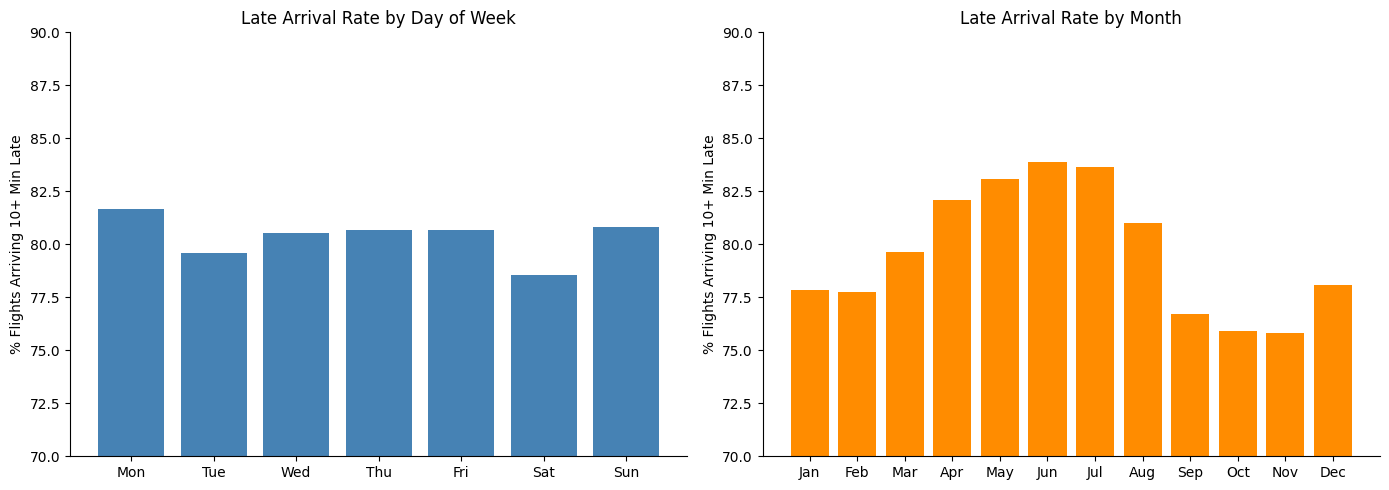

In [7]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# day of week — 0=Monday, 6=Sunday
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_rate = df.groupby('dep_dayofweek')['CHANGE_FLAG_10MIN'].mean() * 100
axes[0].bar(day_labels, day_rate.values, color='steelblue')
axes[0].set_title('Late Arrival Rate by Day of Week', fontsize=12)
axes[0].set_ylabel('% Flights Arriving 10+ Min Late')
axes[0].set_ylim(70, 90)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_rate = df.groupby('dep_month')['CHANGE_FLAG_10MIN'].mean() * 100
axes[1].bar(month_labels, month_rate.values, color='darkorange')
axes[1].set_title('Late Arrival Rate by Month', fontsize=12)
axes[1].set_ylabel('% Flights Arriving 10+ Min Late')
axes[1].set_ylim(70, 90)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/shilppatel/Desktop/AA_FINAL_PROJECT/delay_patterns.png', dpi=150)
plt.show()


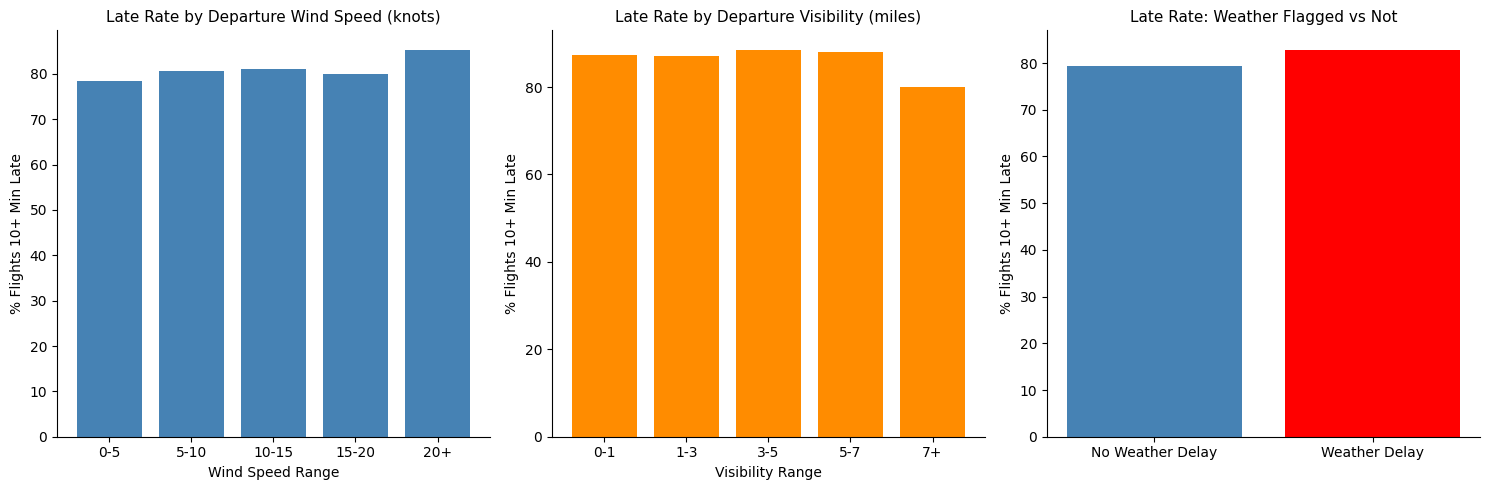

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# wind speed bins
df['wind_bins'] = pd.cut(df['dep_wind_speed'], bins=[0,5,10,15,20,100],
                          labels=['0-5','5-10','10-15','15-20','20+'])
wind_rate = df.groupby('wind_bins', observed=True)['CHANGE_FLAG_10MIN'].mean() * 100
axes[0].bar(wind_rate.index, wind_rate.values, color='steelblue')
axes[0].set_title('Late Rate by Departure Wind Speed (knots)', fontsize=11)
axes[0].set_xlabel('Wind Speed Range')
axes[0].set_ylabel('% Flights 10+ Min Late')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# visibility bins
df['vis_bins'] = pd.cut(df['dep_visibility'], bins=[0,1,3,5,7,50],
                         labels=['0-1','1-3','3-5','5-7','7+'])
vis_rate = df.groupby('vis_bins', observed=True)['CHANGE_FLAG_10MIN'].mean() * 100
axes[1].bar(vis_rate.index, vis_rate.values, color='darkorange')
axes[1].set_title('Late Rate by Departure Visibility (miles)', fontsize=11)
axes[1].set_xlabel('Visibility Range')
axes[1].set_ylabel('% Flights 10+ Min Late')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# weather delay flag
flag_rate = df.groupby('weather_delay_flag')['CHANGE_FLAG_10MIN'].mean() * 100
axes[2].bar(['No Weather Delay', 'Weather Delay'], flag_rate.values, color=['steelblue','red'])
axes[2].set_title('Late Rate: Weather Flagged vs Not', fontsize=11)
axes[2].set_ylabel('% Flights 10+ Min Late')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/shilppatel/Desktop/AA_FINAL_PROJECT/weather_impact.png', dpi=150)
plt.show()


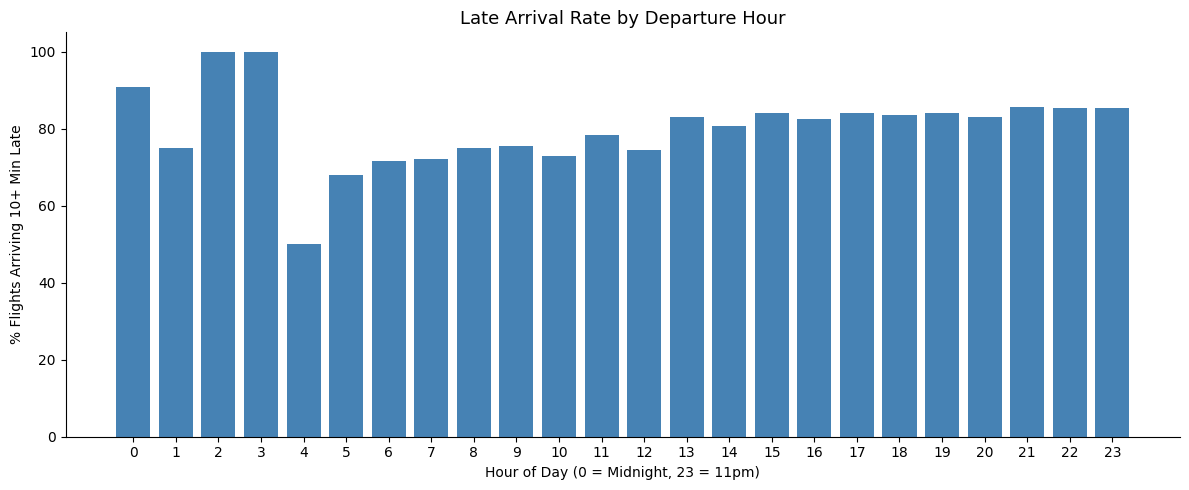

In [9]:
hour_rate = df.groupby('dep_hour')['CHANGE_FLAG_10MIN'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hour_rate.index, hour_rate.values, color='steelblue')
ax.set_title('Late Arrival Rate by Departure Hour', fontsize=13)
ax.set_xlabel('Hour of Day (0 = Midnight, 23 = 11pm)')
ax.set_ylabel('% Flights Arriving 10+ Min Late')
ax.set_xticks(range(0, 24))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/shilppatel/Desktop/AA_FINAL_PROJECT/delay_by_hour.png', dpi=150)
plt.show()


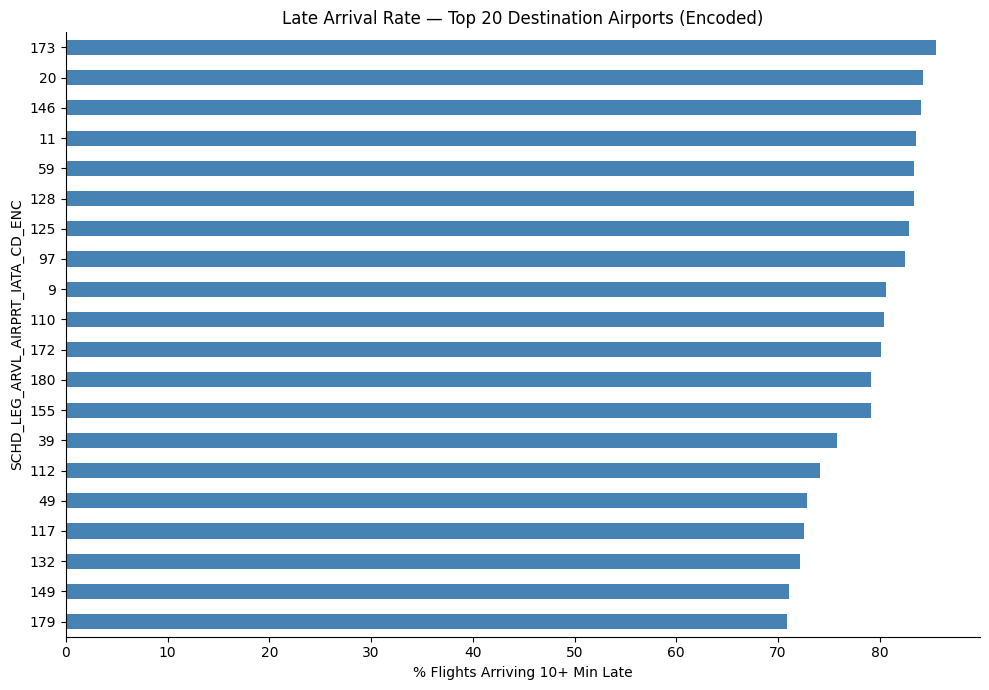

In [10]:
# top 20 airports by flight volume, then show their late rate
top_airports = df['SCHD_LEG_ARVL_AIRPRT_IATA_CD_ENC'].value_counts().head(20).index
df_top = df[df['SCHD_LEG_ARVL_AIRPRT_IATA_CD_ENC'].isin(top_airports)]

airport_rate = df_top.groupby('SCHD_LEG_ARVL_AIRPRT_IATA_CD_ENC')['CHANGE_FLAG_10MIN'].mean() * 100
airport_rate = airport_rate.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
airport_rate.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Late Arrival Rate — Top 20 Destination Airports (Encoded)', fontsize=12)
ax.set_xlabel('% Flights Arriving 10+ Min Late')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/shilppatel/Desktop/AA_FINAL_PROJECT/delay_by_airport.png', dpi=150)
plt.show()


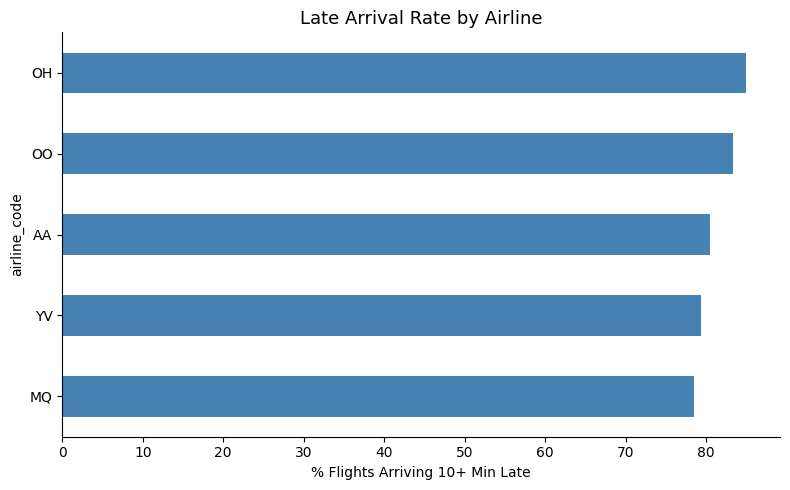


Flight counts per airline:
airline_code
AA    138953
MQ     38386
OO     16890
YV     12921
OH      4650
Name: count, dtype: int64


In [11]:
# hardcode the airline mapping — only 5 airlines, sorted alphabetically
airline_map = {0: 'AA', 1: 'MQ', 2: 'OH', 3: 'OO', 4: 'YV'}
df['airline_code'] = df['OPERAT_AIRLN_IATA_CD_ENC'].map(airline_map)

airline_rate = df.groupby('airline_code')['CHANGE_FLAG_10MIN'].mean() * 100
airline_rate = airline_rate.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
airline_rate.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Late Arrival Rate by Airline', fontsize=13)
ax.set_xlabel('% Flights Arriving 10+ Min Late')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/shilppatel/Desktop/AA_FINAL_PROJECT/delay_by_airline.png', dpi=150)
plt.show()

# print flight counts per airline so we know the sample sizes
print("\nFlight counts per airline:")
print(df['airline_code'].value_counts())


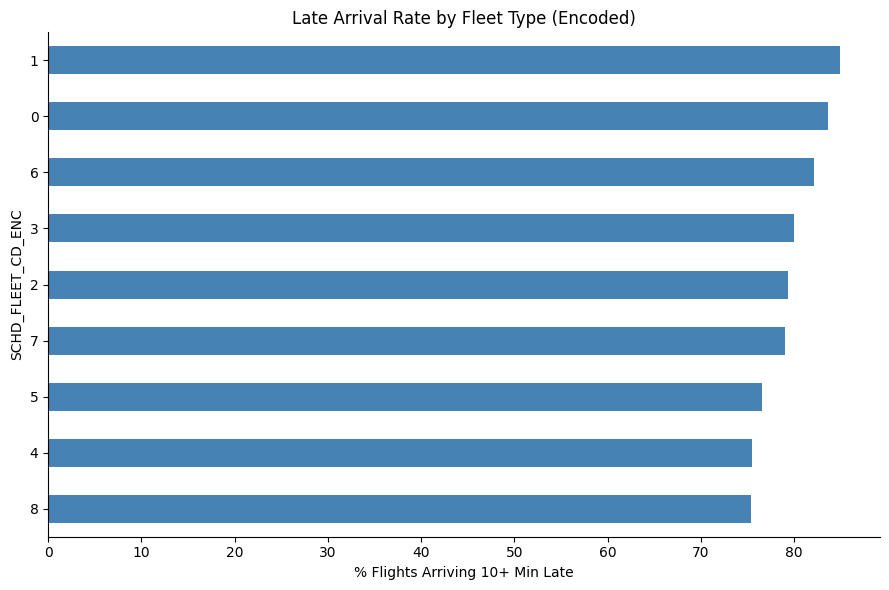


Fleet counts (top 10):
SCHD_FLEET_CD_ENC
2    54211
3    53718
6    34458
7    33093
0    19620
1     9116
8     5296
4     1219
5     1068
9        1
Name: count, dtype: int64


In [12]:
fleet_rate = df.groupby('SCHD_FLEET_CD_ENC')['CHANGE_FLAG_10MIN'].mean() * 100
fleet_counts = df['SCHD_FLEET_CD_ENC'].value_counts()

# only keep fleet types with more than 1000 flights — avoid noisy small samples
valid_fleets = fleet_counts[fleet_counts > 1000].index
fleet_rate = fleet_rate[fleet_rate.index.isin(valid_fleets)].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
fleet_rate.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Late Arrival Rate by Fleet Type (Encoded)', fontsize=12)
ax.set_xlabel('% Flights Arriving 10+ Min Late')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/shilppatel/Desktop/AA_FINAL_PROJECT/delay_by_fleet.png', dpi=150)
plt.show()

print("\nFleet counts (top 10):")
print(fleet_counts.head(10))


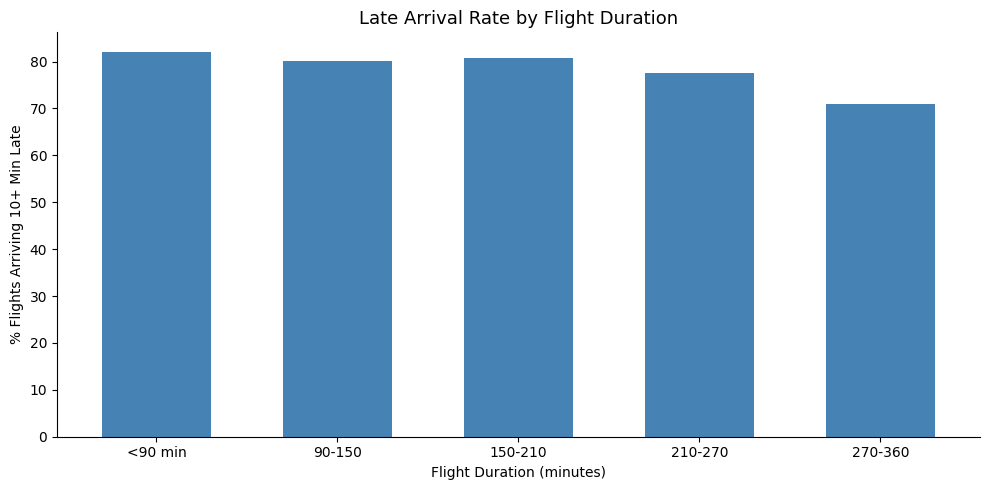


Flight counts per duration bin:
duration_bins
<90 min    82340
90-150     62225
150-210    28383
210-270    34666
270-360     4186
Name: CHANGE_FLAG_10MIN, dtype: int64


In [13]:
# bin flight duration into ranges
df['duration_bins'] = pd.cut(
    df['flight_duration_min'],
    bins=[0, 90, 150, 210, 270, 360, 1440],
    labels=['<90 min', '90-150', '150-210', '210-270', '270-360', '360+']
)

duration_rate  = df.groupby('duration_bins', observed=True)['CHANGE_FLAG_10MIN'].mean() * 100
duration_counts = df.groupby('duration_bins', observed=True)['CHANGE_FLAG_10MIN'].count()

fig, ax = plt.subplots(figsize=(10, 5))
duration_rate.plot(kind='bar', ax=ax, color='steelblue', width=0.6)
ax.set_title('Late Arrival Rate by Flight Duration', fontsize=13)
ax.set_xlabel('Flight Duration (minutes)')
ax.set_ylabel('% Flights Arriving 10+ Min Late')
ax.set_xticklabels(duration_rate.index, rotation=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/shilppatel/Desktop/AA_FINAL_PROJECT/delay_by_duration.png', dpi=150)
plt.show()

print("\nFlight counts per duration bin:")
print(duration_counts)


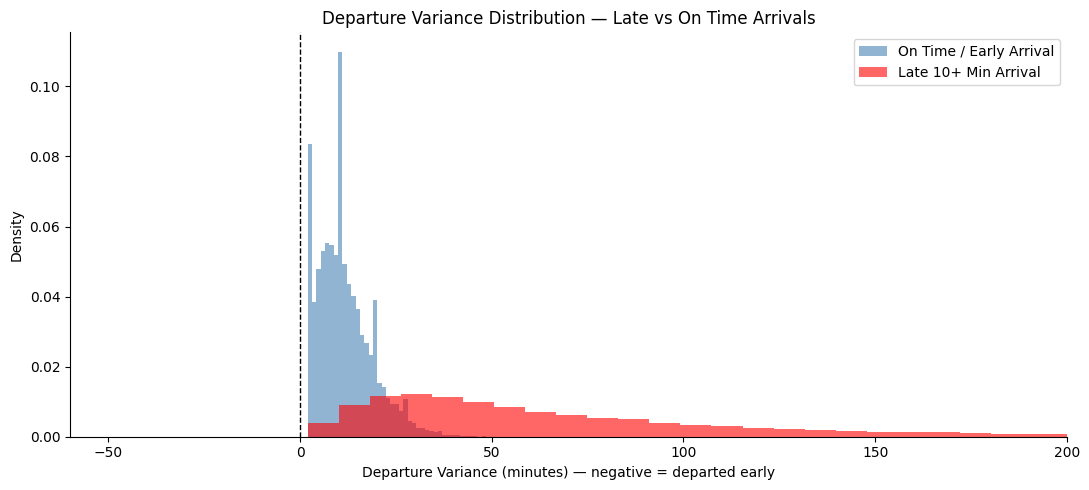

On-time flights  — avg departure variance: 11.7 min
Late flights     — avg departure variance: 78.0 min


In [14]:
fig, ax = plt.subplots(figsize=(11, 5))

# separate late and on-time flights
late_flights   = df[df['CHANGE_FLAG_10MIN'] == 1]['LEG_DEP_VARNCE_MIN_QTY']
ontime_flights = df[df['CHANGE_FLAG_10MIN'] == 0]['LEG_DEP_VARNCE_MIN_QTY']

ax.hist(ontime_flights, bins=60, alpha=0.6, color='steelblue', label='On Time / Early Arrival', density=True)
ax.hist(late_flights,   bins=60, alpha=0.6, color='red',       label='Late 10+ Min Arrival',  density=True)

ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.set_title('Departure Variance Distribution — Late vs On Time Arrivals', fontsize=12)
ax.set_xlabel('Departure Variance (minutes) — negative = departed early')
ax.set_ylabel('Density')
ax.set_xlim(-60, 200)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/shilppatel/Desktop/AA_FINAL_PROJECT/dep_variance_dist.png', dpi=150)
plt.show()

print("On-time flights  — avg departure variance:", round(ontime_flights.mean(), 1), "min")
print("Late flights     — avg departure variance:", round(late_flights.mean(), 1), "min")


In [15]:
total_flights    = len(df)
weather_flagged  = df['weather_delay_flag'].sum()
weather_and_late = df[(df['weather_delay_flag'] == 1) & (df['CHANGE_FLAG_10MIN'] == 1)].shape[0]
late_flights     = df['CHANGE_FLAG_10MIN'].sum()

print(f"Total flights              : {total_flights:,}")
print(f"Weather flagged flights    : {weather_flagged:,} ({weather_flagged/total_flights*100:.1f}% of all flights)")
print(f"Weather flagged AND late   : {weather_and_late:,} ({weather_and_late/late_flights*100:.1f}% of all late flights)")
print(f"Weather flagged but on time: {weather_flagged - weather_and_late:,}")


Total flights              : 211,800
Weather flagged flights    : 67,138 (31.7% of all flights)
Weather flagged AND late   : 55,624 (32.7% of all late flights)
Weather flagged but on time: 11,514


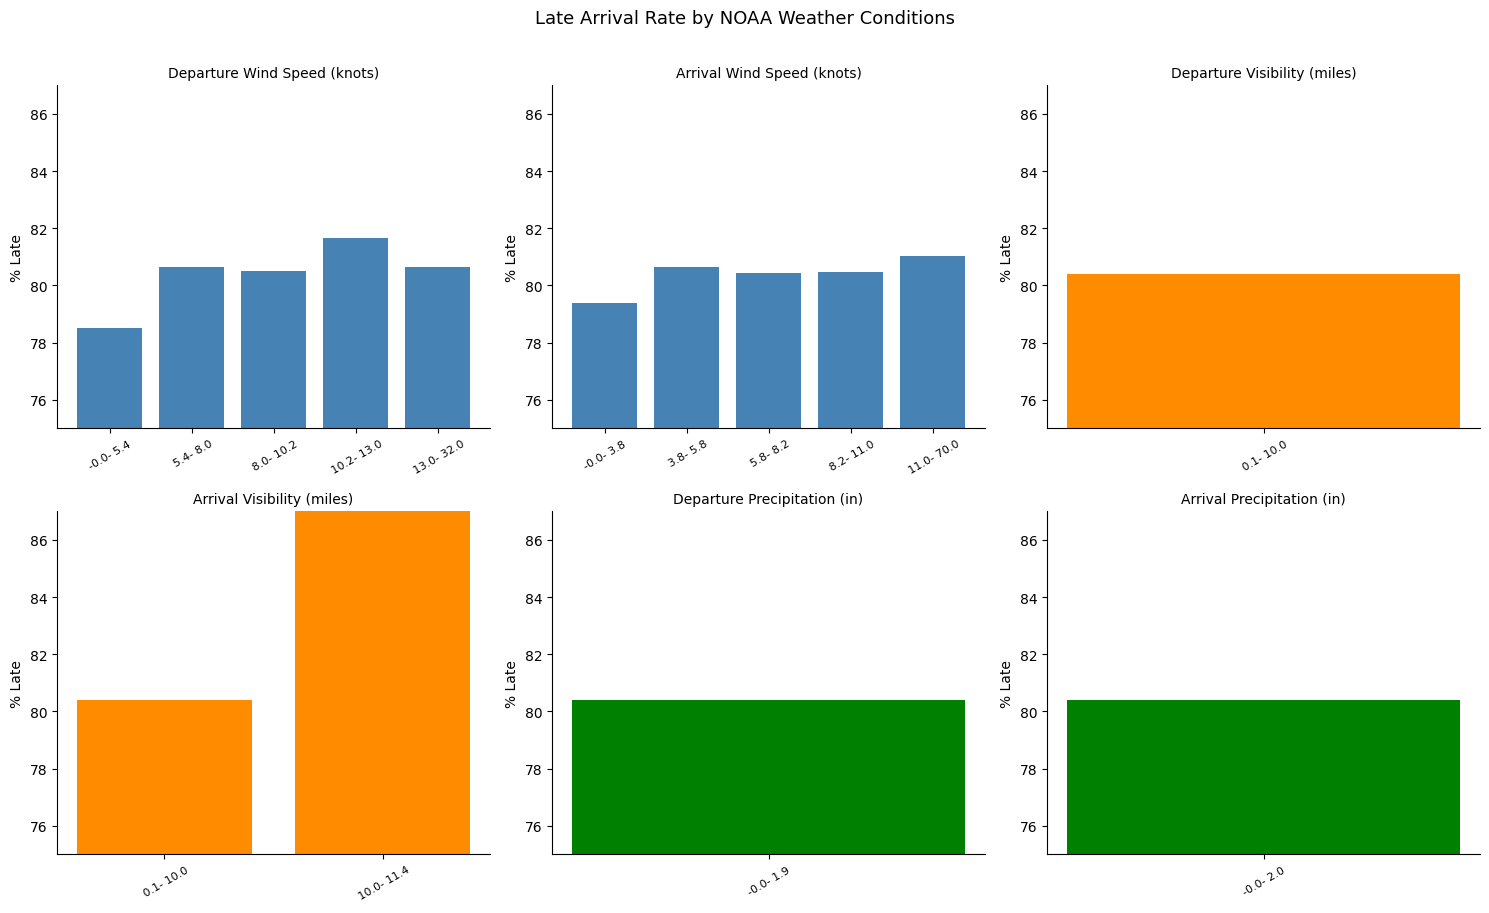

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

weather_features = [
    ('dep_wind_speed',    'Departure Wind Speed (knots)',  axes[0,0], 'steelblue'),
    ('arvl_wind_speed',   'Arrival Wind Speed (knots)',    axes[0,1], 'steelblue'),
    ('dep_visibility',    'Departure Visibility (miles)',  axes[0,2], 'darkorange'),
    ('arvl_visibility',   'Arrival Visibility (miles)',    axes[1,0], 'darkorange'),
    ('dep_precipitation', 'Departure Precipitation (in)', axes[1,1], 'green'),
    ('arvl_precipitation','Arrival Precipitation (in)',   axes[1,2], 'green'),
]

for col, title, ax, color in weather_features:
    bins = pd.qcut(df[col], q=5, duplicates='drop')
    rate = df.groupby(bins, observed=True)['CHANGE_FLAG_10MIN'].mean() * 100
    labels = [f"{float(str(i).split(',')[0].strip('([]')): .1f}-{float(str(i).split(',')[1].strip('(])')): .1f}"
              for i in rate.index]
    ax.bar(range(len(rate)), rate.values, color=color)
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(labels, rotation=30, fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('% Late')
    ax.set_ylim(75, 87)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Late Arrival Rate by NOAA Weather Conditions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/Users/shilppatel/Desktop/AA_FINAL_PROJECT/noaa_weather_impact.png', dpi=150)
plt.show()


In [17]:
print("=" * 50)
print("NOAA WEATHER IMPACT ON LATE ARRIVALS")
print("=" * 50)

# wind speed — departure
print("\nDeparture Wind Speed:")
bins = [0, 5, 10, 15, 20, 100]
labels = ['0-5 knots', '5-10', '10-15', '15-20', '20+']
df['dep_wind_bins'] = pd.cut(df['dep_wind_speed'], bins=bins, labels=labels)
print(df.groupby('dep_wind_bins', observed=True)['CHANGE_FLAG_10MIN'].mean().mul(100).round(1).to_string())

# wind speed — arrival
print("\nArrival Wind Speed:")
df['arvl_wind_bins'] = pd.cut(df['arvl_wind_speed'], bins=bins, labels=labels)
print(df.groupby('arvl_wind_bins', observed=True)['CHANGE_FLAG_10MIN'].mean().mul(100).round(1).to_string())

# visibility — departure
print("\nDeparture Visibility:")
print(f"  Below 5 miles : {df[df['dep_visibility'] < 5]['CHANGE_FLAG_10MIN'].mean()*100:.1f}%")
print(f"  5 miles+      : {df[df['dep_visibility'] >= 5]['CHANGE_FLAG_10MIN'].mean()*100:.1f}%")

# visibility — arrival
print("\nArrival Visibility:")
print(f"  Below 5 miles : {df[df['arvl_visibility'] < 5]['CHANGE_FLAG_10MIN'].mean()*100:.1f}%")
print(f"  5 miles+      : {df[df['arvl_visibility'] >= 5]['CHANGE_FLAG_10MIN'].mean()*100:.1f}%")

# precipitation — departure
print("\nDeparture Precipitation:")
print(f"  No rain       : {df[df['dep_precipitation'] == 0]['CHANGE_FLAG_10MIN'].mean()*100:.1f}%")
print(f"  Rain present  : {df[df['dep_precipitation'] > 0]['CHANGE_FLAG_10MIN'].mean()*100:.1f}%")

# precipitation — arrival
print("\nArrival Precipitation:")
print(f"  No rain       : {df[df['arvl_precipitation'] == 0]['CHANGE_FLAG_10MIN'].mean()*100:.1f}%")
print(f"  Rain present  : {df[df['arvl_precipitation'] > 0]['CHANGE_FLAG_10MIN'].mean()*100:.1f}%")


NOAA WEATHER IMPACT ON LATE ARRIVALS

Departure Wind Speed:
dep_wind_bins
0-5 knots    78.4
5-10         80.6
10-15        81.1
15-20        80.0
20+          85.3

Arrival Wind Speed:
arvl_wind_bins
0-5 knots    79.9
5-10         80.5
10-15        80.7
15-20        81.1
20+          83.6

Departure Visibility:
  Below 5 miles : 88.0%
  5 miles+      : 80.1%

Arrival Visibility:
  Below 5 miles : 84.0%
  5 miles+      : 80.3%

Departure Precipitation:
  No rain       : 79.2%
  Rain present  : 90.2%

Arrival Precipitation:
  No rain       : 79.9%
  Rain present  : 84.9%


In [18]:
# define bad NOAA weather — any one of these conditions
bad_noaa = (
    (df['dep_wind_speed'] > 15) |
    (df['arvl_wind_speed'] > 15) |
    (df['dep_visibility'] < 5)  |
    (df['arvl_visibility'] < 5) |
    (df['dep_precipitation'] > 0) |
    (df['arvl_precipitation'] > 0)
)

late = df['CHANGE_FLAG_10MIN'] == 1

# combine both sources — official AA flag OR bad NOAA conditions
weather_related = df['weather_delay_flag'] == 1
combined_weather = weather_related | bad_noaa

total_late = late.sum()

print("WEATHER IMPACT ON LATE FLIGHTS")
print("=" * 45)
print(f"Total late flights               : {total_late:,}")
print(f"\nOfficially weather flagged (AA)  : {(late & weather_related).sum():,}  ({(late & weather_related).sum()/total_late*100:.1f}%)")
print(f"Bad NOAA conditions              : {(late & bad_noaa).sum():,}  ({(late & bad_noaa).sum()/total_late*100:.1f}%)")
print(f"\nCombined (either source)         : {(late & combined_weather).sum():,}  ({(late & combined_weather).sum()/total_late*100:.1f}%)")
print(f"No weather involvement at all    : {(late & ~combined_weather).sum():,}  ({(late & ~combined_weather).sum()/total_late*100:.1f}%)")


WEATHER IMPACT ON LATE FLIGHTS
Total late flights               : 170,272

Officially weather flagged (AA)  : 55,624  (32.7%)
Bad NOAA conditions              : 59,426  (34.9%)

Combined (either source)         : 94,979  (55.8%)
No weather involvement at all    : 75,293  (44.2%)


In [19]:
late = df['CHANGE_FLAG_10MIN'] == 1
weather_related = df['weather_delay_flag'] == 1
bad_noaa = (
    (df['dep_wind_speed'] > 15) |
    (df['arvl_wind_speed'] > 15) |
    (df['dep_visibility'] < 5)  |
    (df['arvl_visibility'] < 5) |
    (df['dep_precipitation'] > 0) |
    (df['arvl_precipitation'] > 0)
)

both = weather_related & bad_noaa & late
only_flag = weather_related & ~bad_noaa & late
only_noaa = ~weather_related & bad_noaa & late
total_late = late.sum()

print("BREAKDOWN OF WEATHER-RELATED LATE FLIGHTS")
print("=" * 50)
print(f"Both AA flag AND bad NOAA conditions : {both.sum():,}  ({both.sum()/total_late*100:.1f}%)")
print(f"Only AA flag (no bad NOAA)           : {only_flag.sum():,}  ({only_flag.sum()/total_late*100:.1f}%)")
print(f"Only bad NOAA (no AA flag)           : {only_noaa.sum():,}  ({only_noaa.sum()/total_late*100:.1f}%)")
print(f"\nAs % of ALL 211,800 flights:")
print(f"Both sources confirmed weather       : {both.sum()/len(df)*100:.1f}%")


BREAKDOWN OF WEATHER-RELATED LATE FLIGHTS
Both AA flag AND bad NOAA conditions : 20,071  (11.8%)
Only AA flag (no bad NOAA)           : 35,553  (20.9%)
Only bad NOAA (no AA flag)           : 39,355  (23.1%)

As % of ALL 211,800 flights:
Both sources confirmed weather       : 9.5%


In [20]:
late          = df['CHANGE_FLAG_10MIN'] == 1
departed_ontime = df['LEG_DEP_VARNCE_MIN_QTY'] <= 10   # departed within 10 min of schedule
combined_weather = (df['weather_delay_flag'] == 1) | (
    (df['dep_wind_speed'] > 15) |
    (df['arvl_wind_speed'] > 15) |
    (df['dep_visibility'] < 5)  |
    (df['arvl_visibility'] < 5) |
    (df['dep_precipitation'] > 0) |
    (df['arvl_precipitation'] > 0)
)

# purely weather caused — departed on time, weather present, still arrived late
purely_weather = late & departed_ontime & combined_weather

print("PURELY WEATHER CAUSED LATE ARRIVALS")
print("=" * 45)
print(f"Total flights                     : {len(df):,}")
print(f"Departed on time (<= 10 min late) : {departed_ontime.sum():,}")
print(f"Purely weather caused late        : {purely_weather.sum():,}  ({purely_weather.sum()/len(df)*100:.1f}% of all flights)")
print(f"                                    ({purely_weather.sum()/late.sum()*100:.1f}% of all late flights)")


PURELY WEATHER CAUSED LATE ARRIVALS
Total flights                     : 211,800
Departed on time (<= 10 min late) : 26,143
Purely weather caused late        : 2,998  (1.4% of all flights)
                                    (1.8% of all late flights)
